In [2]:
#1
%matplotlib inline 
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import matplotlib.pyplot as plt
import helper_functions as hlp


torch.set_default_dtype(torch.float64)


T = 60e-6           
B = 2e6             
Fs = 5 * B          
N = int(np.round(T * Fs)) 

N_fft = 2**14


t_np = np.linspace(0, T, N, endpoint=False)
t = torch.tensor(t_np, dtype=torch.float64)

t_norm = t / torch.max(t)

b_slope = B/T
psi = 2 * np.pi * (b_slope/2) * t**2
a = 1
s_base = a * torch.complex(torch.cos(psi), torch.sin(psi))

null_freqs = [0.2e6, 0.3e6, 0.4e6] 
print(f"Targets defined at: {[f/1e6 for f in null_freqs]} MHz")

# Steering Matrix
steering_vectors = []
for f in null_freqs:
    w = 2 * np.pi * f
    vec = torch.complex(torch.cos(w * t), -torch.sin(w * t))
    steering_vectors.append(vec)

steering_matrix = torch.stack(steering_vectors)


z = torch.tensor(hlp.build_z(a,psi,t,null_freqs))
print(torch._shape_as_tensor(z))

Targets defined at: [0.2, 0.3, 0.4] MHz
tensor([600,   3])


In [6]:
from version1 import getphi
phi_start =  torch.tensor(getphi(null_freqs), dtype=torch.float64, requires_grad=True)
print("initial_phi_shape:", phi_start.shape)

phi_start = phi_start.squeeze()
print("initial_phi_shape_after_squeeze:", phi_start.shape)




initial_phi_shape: torch.Size([600, 1])
initial_phi_shape_after_squeeze: torch.Size([600])


In [4]:
# יצירת וקטור רנדומלי בטווח [15 ,15-]
#phi_start = (30 * torch.rand(600, dtype=torch.float64) - 15).detach().requires_grad_(True)

phi_start = torch.zeros(N, dtype=torch.float64, requires_grad=True)
print("initial_phi_shape:", phi_start.shape)


initial_phi_shape: torch.Size([600])


In [23]:
# 2
import copy 


phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)

# Check that phi has the correct shape
if phi.shape != (N,):
    raise ValueError(f"Expected phi to have shape ({N},), but got {phi.shape}")

learning_rate =  0.010640845633353869
iterations = 10000 
beta_smooth = 2.6721252174776165e-05
beta_norm = 0 # 1.0914710219012044e-05
beta_div1 = 0
beta_div2 = 0

optimizer = torch.optim.Adam([phi], lr=learning_rate)

print(f"Starting Multi-Null Optimization ({iterations} iterations)...")
print(f"Saving best model based on Minimum Total Loss (Energy + Regularization)")

loss_history = []


best_loss = float('inf') 
best_phi = None
best_epoch = 0

for i in range(iterations):
    
    correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
    s_transmit = s_base * correction_phasor
    
   
    spectral_vals = torch.matmul(steering_matrix, s_transmit)
    energies = torch.abs(spectral_vals)**2
    
     
    loss_nulls = torch.sum(energies) 
    
    diff_phi = phi[1:] - phi[:-1]
    reg_term = beta_smooth * torch.sum(diff_phi**2)
    
    
    loss_norm = beta_norm * torch.sum(phi**2)

    if beta_div1 > 0 or beta_div2 > 0:
        integrals1 = [
            torch.trapezoid(z[:, k] * correction_phasor * t_norm, x=t_norm) 
            for k in range(z.shape[1])
        ]

        loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])


        integrals2 = [
            torch.trapezoid(z[:, k] * correction_phasor * (t_norm**2), x=t_norm) 
            for k in range(z.shape[1])
        ]
        loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])
    else:
        loss_div1 = 0
        loss_div2 = 0
        
    loss = loss_norm  + loss_div1 + loss_div2  + loss_nulls # + reg_term
    
    
    if loss.item() < best_loss:
        best_loss = loss.item()
        best_phi = phi.clone() 
        best_epoch = i
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    
    if i % 1000 == 0:
        print(f"Iter {i}: Total Loss = {loss.item():.6f}")
       
        max_depth = 10 * np.log10(torch.max(energies).item() + 1e-40)
        print(f"   Worst Null Depth: {max_depth:.2f} dB")

print("\n--- Optimization Finished ---")
print(f"Restoring best model from Epoch {best_epoch} (Total Loss: {best_loss:.6f})")


with torch.no_grad():
    phi.copy_(best_phi)



final_spectral = torch.matmul(steering_matrix, s_base * torch.complex(torch.cos(phi), torch.sin(phi)))
final_energies = torch.abs(final_spectral)**2
print("Null Depths in Selected Model:")
for k, f in enumerate(null_freqs):

    e_db = 10 * np.log10(final_energies[k].item())
    print(f"Freq {f/1e6} MHz: {e_db:.2f} dB")

C:\Users\Elad\AppData\Local\Temp\ipykernel_26140\95924471.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  phi = torch.tensor(phi_start, dtype=torch.float64, requires_grad=True)


Starting Multi-Null Optimization (10000 iterations)...
Saving best model based on Minimum Total Loss (Energy + Regularization)
Iter 0: Total Loss = 8.253639
   Worst Null Depth: 6.29 dB
Iter 1000: Total Loss = 0.000054
   Worst Null Depth: -45.20 dB
Iter 2000: Total Loss = 0.018700
   Worst Null Depth: -21.22 dB
Iter 3000: Total Loss = 0.015613
   Worst Null Depth: -19.91 dB
Iter 4000: Total Loss = 0.003922
   Worst Null Depth: -26.61 dB
Iter 5000: Total Loss = 0.074580
   Worst Null Depth: -13.34 dB
Iter 6000: Total Loss = 0.001410
   Worst Null Depth: -31.28 dB
Iter 7000: Total Loss = 0.005897
   Worst Null Depth: -24.43 dB
Iter 8000: Total Loss = 0.002795
   Worst Null Depth: -29.93 dB
Iter 9000: Total Loss = 0.000467
   Worst Null Depth: -35.88 dB

--- Optimization Finished ---
Restoring best model from Epoch 398 (Total Loss: 0.000000)
Null Depths in Selected Model:
Freq 0.2 MHz: -195.78 dB
Freq 0.3 MHz: -192.49 dB
Freq 0.4 MHz: -181.58 dB


--- True Null Depths (Calculated Mathematically) ---
Freq 0.2 MHz: -232.01 dB
Freq 0.3 MHz: -228.72 dB
Freq 0.4 MHz: -217.82 dB


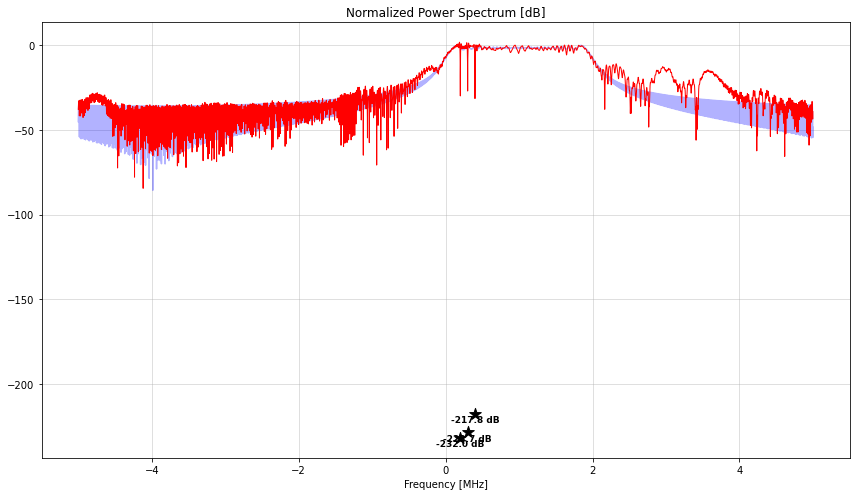

In [24]:
#3
null_freqs_np = np.array(null_freqs) 


with torch.no_grad():
    correction_phasor = torch.complex(torch.cos(best_phi), torch.sin(best_phi))
    s_transmit_best = s_base * correction_phasor
    
    phi_learned = best_phi.detach().cpu().numpy()
    s_final_np = s_transmit_best.detach().cpu().numpy()


freqs = np.fft.fftshift(np.fft.fftfreq(N_fft, 1/Fs))


S_orig = np.fft.fftshift(np.fft.fft(s_base.numpy(), n=N_fft))
S_final = np.fft.fftshift(np.fft.fft(s_final_np, n=N_fft))


S_orig_db = 20*np.log10(np.abs(S_orig) + 1e-15)
S_final_db = 20*np.log10(np.abs(S_final) + 1e-15)


peak_ref = np.max(S_orig_db)
S_orig_norm = S_orig_db - peak_ref
S_final_norm = S_final_db - peak_ref


with torch.no_grad():
    # חישוב ב-PyTorch
    exact_vals = torch.matmul(steering_matrix, s_transmit_best)
    energies_torch = torch.abs(exact_vals)**2
    
    # המרה מסודרת ל-Numpy
    energies_np = energies_torch.detach().cpu().numpy()
    
    # חישוב dB ב-Numpy
    exact_db_absolute = 10 * np.log10(energies_np + 1e-40)
    
    # נרמול
    exact_db_relative = exact_db_absolute - peak_ref

print("--- True Null Depths (Calculated Mathematically) ---")
for k, f_val in enumerate(null_freqs_np):
    print(f"Freq {f_val/1e6} MHz: {exact_db_relative[k]:.2f} dB")


# 5. הציור
plt.figure(figsize=(12, 7))

# גרף האות המקורי
plt.plot(freqs/1e6, S_orig_norm, label='Original LFM', color='blue', alpha=0.3)

# גרף האות האופטימלי (FFT)
plt.plot(freqs/1e6, S_final_norm, label='Optimized Signal', color='red', linewidth=1)

# הוספת הכוכבים

plt.scatter(null_freqs_np/1e6, exact_db_relative, 
            color='black', marker='*', s=150, zorder=10, 
            label='Exact Analytical Depth')

# הוספת טקסט ליד הכוכבים
for k, f_val in enumerate(null_freqs_np):
    depth = exact_db_relative[k]
    plt.text(f_val/1e6, depth - 5, f"{depth:.1f} dB", 
             color='black', fontweight='bold', ha='center', fontsize=9)

plt.title("Normalized Power Spectrum [dB]")
plt.xlabel("Frequency [MHz]")

#plt.legend(loc='upper right')
plt.grid(True, alpha=0.5)
#plt.xlim(0, B/1e6 + 0.2)
#plt.ylim(-150, 5)
plt.tight_layout()
plt.show()

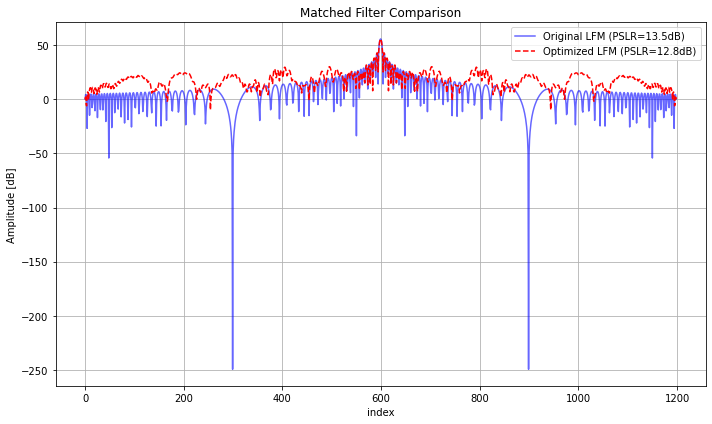

--- PSLR Performence ---
Selected Model based on Minimum Total Loss
Original LFM PSLR:  13.46 dB
Optimized LFM PSLR: 12.81 dB
Degradation:        0.65 dB
Notice, PSLR should be as high as possible, so positive degradation is bad.

--- ISLR Performance ---
Original LFM ISLR:  -9.83 dB
Optimized LFM ISLR: -7.41 dB
Degradation:        -2.42 dB
Notice, ISLR should be as small as possible, so negative degradation is bad.



In [25]:
#4 - Matched Filter and PSLR Calculation
with torch.no_grad():
    correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
    s_best_time_domain = s_base * correction_phasor
    s_best_np = s_best_time_domain.detach().numpy()
    s_base_np = s_base.numpy()

def calculate_mf_and_pslr(signal):
    
    matched_filter = np.conj(signal[::-1])
    
    mf = np.convolve(signal, matched_filter, mode='full')
    
    mf_abs = np.abs(mf)
    mf_db = 20 * np.log10(mf_abs + 1e-20)
    
    # PSLR Calculation
    center_idx = len(mf_db) // 2
    main_lobe_width_seconds = 2 / B
    margin_samples = int((main_lobe_width_seconds / 2) * Fs)
    
    left_side = mf_db[:center_idx - margin_samples]
    right_side = mf_db[center_idx + margin_samples:]
    
    sidelobe_region = np.concatenate((left_side, right_side))
    max_sidelobe = np.max(sidelobe_region)
    max_mainlobe = np.max(mf_db)
    
    pslr = max_mainlobe - max_sidelobe


    # ISLR calculation
    n_main = np.arange(len(mf_db[center_idx - margin_samples : center_idx + margin_samples]))
    n_left = np.arange(len(left_side))
    n_right = np.arange(len(right_side))

    main_lobe_linear = mf_abs[center_idx - margin_samples : center_idx + margin_samples]
    left_side_linear = mf_abs[:center_idx - margin_samples]
    right_side_linear = mf_abs[center_idx + margin_samples:]

    # discrete options:
    # main_lobe_energy = np.sum(mf_db[center_idx - margin_samples : center_idx + margin_samples] ** 2)
    # sidelobe_energy = np.sum(left_side ** 2) + np.sum(right_side ** 2)    

    main_lobe_energy = np.trapezoid(main_lobe_linear ** 2, x=n_main)
    sidelobe_energy = np.trapezoid(left_side_linear ** 2, x=n_left) + np.trapezoid(right_side_linear ** 2, x=n_right)
    islr = 10 * np.log10(sidelobe_energy / main_lobe_energy + 1e-40)


    return mf_db, pslr, islr


mf_orig_db, pslr_orig, islr_orig = calculate_mf_and_pslr(s_base_np)
mf_new_db, pslr_new, islr_new = calculate_mf_and_pslr(s_best_np)

plt.figure(figsize=(10, 6))
plt.plot(mf_orig_db, label=f'Original LFM (PSLR={pslr_orig:.1f}dB)', color='blue', alpha=0.6)
plt.plot(mf_new_db, label=f'Optimized LFM (PSLR={pslr_new:.1f}dB)', color='red', linestyle='--')

plt.title("Matched Filter Comparison")
plt.xlabel("index")
plt.ylabel("Amplitude [dB]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"--- PSLR Performence ---")
print(f"Selected Model based on Minimum Total Loss")
print(f"Original LFM PSLR:  {pslr_orig:.2f} dB")
print(f"Optimized LFM PSLR: {pslr_new:.2f} dB")
print(f"Degradation:        {pslr_orig - pslr_new:.2f} dB")
print("Notice, PSLR should be as high as possible, so positive degradation is bad.\n")


print(f"--- ISLR Performance ---")
print(f"Original LFM ISLR:  {islr_orig:.2f} dB")
print(f"Optimized LFM ISLR: {islr_new:.2f} dB")
print(f"Degradation:        {islr_orig - islr_new:.2f} dB")
print("Notice, ISLR should be as small as possible, so negative degradation is bad.\n")

# lags = np.arange(-len(s_base_np) + 1, len(s_base_np))
# time_lags = (lags / Fs) * 1e6 



In [26]:
#5
phi_numpy = best_phi.detach().cpu().numpy()


correction_phasor = np.exp(1j * phi_numpy)


filename = 'optimal_phasor.npy'
np.save(filename, correction_phasor)

print(f"Success! Saved optimized phasor to '{filename}'")
print(f"File shape: {correction_phasor.shape}")

Success! Saved optimized phasor to 'optimal_phasor.npy'
File shape: (600,)


In [ ]:
pip install optuna 

  Using cached optuna-4.7.0-py3-none-any.whl.metadata (17 kB)
  Using cached alembic-1.16.5-py3-none-any.whl.metadata (7.3 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
  Using cached sqlalchemy-2.0.46-cp39-cp39-win_amd64.whl.metadata (9.8 kB)
  Using cached mako-1.3.10-py3-none-any.whl.metadata (2.9 kB)
  Using cached greenlet-3.2.5.tar.gz (191 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Using cached optuna-4.7.0-py3-none-any.whl (413 kB)
Using cached alembic-1.16.5-py3-none-any.whl (247 kB)
Using cached sqlalchemy-2.0.46-cp39-cp39-win_amd64.whl (2.1 MB)
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)
Using cached mako-1.3.10-py3-none-any.whl (78 kB)
Failed to build green

  error: subprocess-exited-with-error
  
  × Building wheel for greenlet (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [116 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-39\greenlet
      copying src\greenlet\__init__.py -> build\lib.win-amd64-cpython-39\greenlet
      creating build\lib.win-amd64-cpython-39\greenlet\platform
      copying src\greenlet\platform\__init__.py -> build\lib.win-amd64-cpython-39\greenlet\platform
      creating build\lib.win-amd64-cpython-39\greenlet\tests
      copying src\greenlet\tests\fail_clearing_run_switches.py -> build\lib.win-amd64-cpython-39\greenlet\tests
      copying src\greenlet\tests\fail_cpp_exception.py -> build\lib.win-amd64-cpython-39\greenlet\tests
      copying src\greenlet\tests\fail_initialstub_already_started.py -> build\lib.win-amd64-cpython-39\greenlet\tests
      copying src\greenlet\tests\fail_slp_switch.py -> build\lib.win-amd64

In [18]:
import torch
import numpy as np
import optuna

def objective(trial):
    
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    # b_smooth = trial.suggest_float("beta_smooth", 1e-5, 1.0, log=True)
    b_norm = trial.suggest_float("beta_norm", 1e-5, 1.0, log=True)
    # beta_div1 = trial.suggest_float("beta_div1", 1e-5, 1.0, log=True)
    # beta_div2 = trial.suggest_float("beta_div2", 1e-5, 1.0, log=True)
    
    phi = torch.zeros(N, requires_grad=True, dtype=torch.float64)
    optimizer = torch.optim.Adam([phi], lr=lr)
    
    best_loss = float('inf')
    iterations = 5000 

    
    for i in range(iterations):
        correction_phasor = torch.complex(torch.cos(phi), torch.sin(phi))
        s_transmit = s_base * correction_phasor
        
        spectral_vals = torch.matmul(steering_matrix, s_transmit)
        energies = torch.abs(spectral_vals)**2
        
        loss_nulls = torch.sum(energies) 
        #diff_phi = phi[1:] - phi[:-1]
        #reg_term = b_smooth * torch.sum(diff_phi**2)
        loss_norm = b_norm * torch.sum(phi**2) 
        if((beta_div1) and (beta_div2)):  
            integrals1 = [
                torch.trapezoid(z[:, k] * correction_phasor * t_norm, x=t_norm) 
                for k in range(z.shape[1])
            ]
            loss_div1 = beta_div1 * sum([torch.abs(val)**2 for val in integrals1])    
            integrals2 = [
                torch.trapezoid(z[:, k] * correction_phasor * (t_norm**2), x=t_norm) 
                for k in range(z.shape[1])
            ]
            loss_div2 = beta_div2 * sum([torch.abs(val)**2 for val in integrals2])
        else:
            loss_div1 = 0
            loss_div2 = 0
            
        loss = loss_nulls  + loss_norm + loss_div1 + loss_div2 # + reg_term
        
        
        if loss.item() < best_loss:
            best_loss = loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return best_loss


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30) 

print("Best Parameters found:", study.best_params)

[I 2026-02-24 15:37:59,328] A new study created in memory with name: no-name-ec35c136-63ca-422c-a8c5-2a7a9e6af9fc
[I 2026-02-24 15:38:07,946] Trial 0 finished with value: 0.9215945211879143 and parameters: {'lr': 0.019367801715953495, 'beta_norm': 0.022483708898526217}. Best is trial 0 with value: 0.9215945211879143.
[I 2026-02-24 15:38:14,039] Trial 1 finished with value: 0.33495536748093446 and parameters: {'lr': 0.023286253719381388, 'beta_norm': 0.007903306119011416}. Best is trial 1 with value: 0.33495536748093446.
[I 2026-02-24 15:38:20,616] Trial 2 finished with value: 0.9261851872394423 and parameters: {'lr': 0.03696011435417402, 'beta_norm': 0.022796372571921915}. Best is trial 1 with value: 0.33495536748093446.
[I 2026-02-24 15:38:26,592] Trial 3 finished with value: 0.013757531430155411 and parameters: {'lr': 0.002380896750221339, 'beta_norm': 0.00022966564093437772}. Best is trial 3 with value: 0.013757531430155411.
[I 2026-02-24 15:38:32,631] Trial 4 finished with value: 0

Best Parameters found: {'lr': 0.010640845633353869, 'beta_norm': 1.0914710219012044e-05}
